# Sebaran Data Opinion Dataset

Notebook ini hanya menampilkan sebaran data berdasarkan kolom yang tersedia di `datasets/opinion_datasets_v3.csv`.

In [78]:
from collections import Counter
from pathlib import Path
import polars as pl
import csv
import sys


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "datasets").is_dir():
            return candidate
    return current


try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

ROOT = find_project_root(NOTEBOOK_DIR)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config

DATASET_PATH = config.DATASETS / "opinion_datasets_v3.csv"
FIGURE_DIR = config.FIGURES / "opinion_dataset_distribution"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(DATASET_PATH)

E:\School\tugas-akhir\project\datasets\opinion_datasets_v3.csv


## 1. Load Data

In [79]:
with DATASET_PATH.open(newline="", encoding="utf-8-sig") as file:
    reader = csv.DictReader(file)
    rows = [dict(row) for row in reader]
    columns = list(reader.fieldnames or [])

for row in rows:
    for column in columns:
        value = row.get(column, "")
        row[column] = value.strip() if isinstance(value, str) else value

In [80]:
df = pl.DataFrame(rows)

print(f"Jumlah baris: {df.height}")
print(f"Jumlah kolom: {df.width}")
print(df.columns)
with pl.Config(tbl_rows=-1, tbl_cols=-1, fmt_str_lengths=1000):
    display(df)

Jumlah baris: 41
Jumlah kolom: 38
['opinion_id', 'candidate_id', 'source_reference_no', 'source_id', 'event_id', 'event_group', 'canonical_source_id', 'additional_provenance', 'duplicate_group_id', 'source_title', 'source_date', 'source_location', 'source_url', 'speaker_name', 'speaker_type', 'attributed_by', 'quote_type', 'subjectivity_type', 'text_original', 'text_normalized', 'context_text', 'contextualized_text', 'context_dependency', 'text_verification_status', 'sentiment_target', 'aspect', 'target_scope', 'scope_tier', 'corpus_role', 'atomicity_status', 'extraction_confidence', 'analysis_eligibility', 'evaluation_eligibility', 'exclusion_reason', 'sentiment_label', 'label_status', 'human_review_status', 'annotation_notes']


opinion_id,candidate_id,source_reference_no,source_id,event_id,event_group,canonical_source_id,additional_provenance,duplicate_group_id,source_title,source_date,source_location,source_url,speaker_name,speaker_type,attributed_by,quote_type,subjectivity_type,text_original,text_normalized,context_text,contextualized_text,context_dependency,text_verification_status,sentiment_target,aspect,target_scope,scope_tier,corpus_role,atomicity_status,extraction_confidence,analysis_eligibility,evaluation_eligibility,exclusion_reason,sentiment_label,label_status,human_review_status,annotation_notes
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""OPU-0001""","""CAND-0001""","""""","""SRC-0009""","""EVT-0007""","""BKY-LEM-COMPLAINT-2025""","""SRC-0009""","""SRC-0035""","""DUP-0001""","""Masyarakat Pulau Lemukutan mendambakan listrik 24 jam""","""2025-09-12""","""Desa Pulau Lemukutan, Kecamatan Sungai Raya Kepulauan, Kabupaten Bengkayang""","""https://berkabar.co.id/2025/09/12/wisatawan-terus-meningkat-masyarakat-pulau-lemukutan-bengkayang-dambakan-listrik-24-jam/""","""Nopriandi""","""community_representative""","""""","""indirect""","""public_experience""","""dari tahun 2023 sudah ada wacana untuk listrik 24 jam dengan tenaga solar panel energy baru terbarukan, namun hingga kini belum terealisasi.""","""Sejak 2023 sudah ada wacana listrik 24 jam menggunakan panel surya energi baru terbarukan, tetapi hingga kini belum terealisasi.""","""Wacana penyediaan listrik 24 jam di Pulau Lemukutan direncanakan menggunakan panel surya.""","""Sejak 2023 sudah ada wacana listrik 24 jam menggunakan panel surya energi baru terbarukan, tetapi hingga kini belum terealisasi.""","""none""","""exact_span_verified""","""realisasi_rencana_PLTS""","""implementation_delay""","""direct_PLTS""","""A""","""core_public_opinion""","""atomic""","""0.96""","""yes""","""yes""","""""","""""","""unlabeled""","""source_verified""","""Dipertahankan sebagai opini masyarakat yang menyebut panel surya secara eksplisit."""
"""OPU-0002""","""CAND-0002""","""""","""SRC-0009""","""EVT-0007""","""BKY-LEM-COMPLAINT-2025""","""SRC-0009""","""SRC-0035""","""DUP-0001""","""Masyarakat Pulau Lemukutan mendambakan listrik 24 jam""","""2025-09-12""","""Desa Pulau Lemukutan, Kecamatan Sungai Raya Kepulauan, Kabupaten Bengkayang""","""https://berkabar.co.id/2025/09/12/wisatawan-terus-meningkat-masyarakat-pulau-lemukutan-bengkayang-dambakan-listrik-24-jam/""","""Nopriandi""","""community_representative""","""""","""direct""","""public_experience""","""fasilitas yg kami berikan masih belum optimal karena keterbatasan listrik""","""Fasilitas yang kami berikan masih belum optimal karena keterbatasan listrik.""","""Kalimat sebelumnya membahas rencana listrik 24 jam menggunakan panel surya yang belum terealisasi.""","""Fasilitas yang kami berikan masih belum optimal karena keterbatasan listrik.""","""previous_sentence""","""exact_span_verified""","""ketersediaan_listrik""","""service_limitation""","""electricity_context_linked_to_PLTS""","""A""","""core_public_opinion""","""atomic""","""0.99""","""conditional""","""review_required""","""""","""""","""unlabeled""","""source_verified_scope_review_required""","""Hubungan dengan PLTS berasal dari kalimat sebelumnya.; Hubungan dengan PLTS bergantung pada kalimat sebelumnya."""
"""OPU-0003""","""CAND-0003""","""""","""SRC-0009""","""EVT-0007""","""BKY-LEM-COMPLAINT-2025""","""SRC-0009""","""SRC-0035""","""DUP-0001""","""Masyarakat Pulau Lemukutan mendambakan listrik 24 jam""","""2025-09-12""","""Desa Pulau Lemukutan, Kecamatan Sungai Raya Kepulauan, Kabupaten Bengkayang""","""https://berkabar.co.id/2025/09/12/wisatawan-terus-meningkat-masyarakat-pulau-lemukutan-bengkayang-dambakan-listrik-24-jam/""","""Masyarakat Desa Pulau Lemukutan""","""community_collective""","""Nopriandi""","""indirect_collective_attribution""","""public_expectation""","""seluruh ma

## 2. Visualisasi

In [81]:
import matplotlib.pyplot as plt


def clean_value(value):
    return value if value else "(kosong)"


def value_counts(column, top=None):
    counts = Counter(clean_value(row.get(column, "")) for row in rows)
    items = counts.most_common(top)
    return dict(items)


def plot_bar(column, title=None, top=None, figsize=(9, 4)):
    data = value_counts(column, top=top)
    labels = list(data.keys())
    values = list(data.values())

    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(labels, values, color="#2f6f9f")
    ax.set_title(title or column)
    ax.set_ylabel("Jumlah")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{column}.png", dpi=160)
    plt.show()


def plot_horizontal_bar(column, title=None, top=10, figsize=(9, 5)):
    data = value_counts(column, top=top)
    labels = list(data.keys())[::-1]
    values = list(data.values())[::-1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(labels, values, color="#2f6f9f")
    ax.set_title(title or column)
    ax.set_xlabel("Jumlah")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"{column}_top{top}.png", dpi=160)
    plt.show()

## 3. Sebaran Status Data

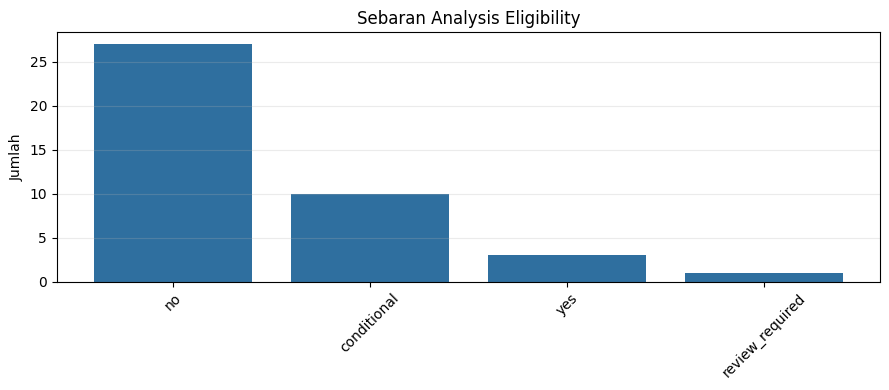

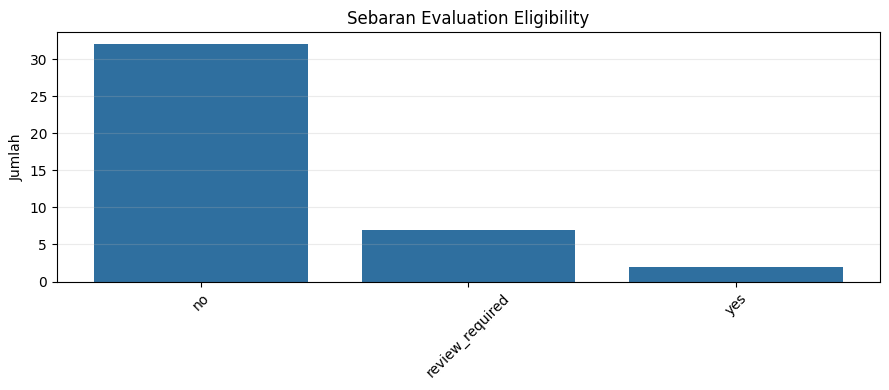

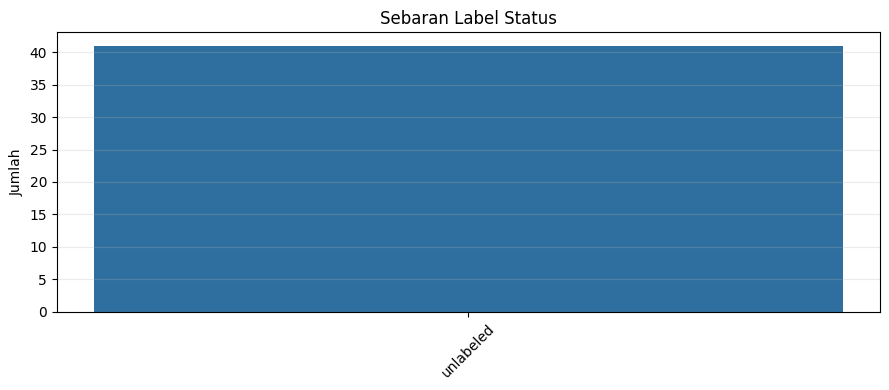

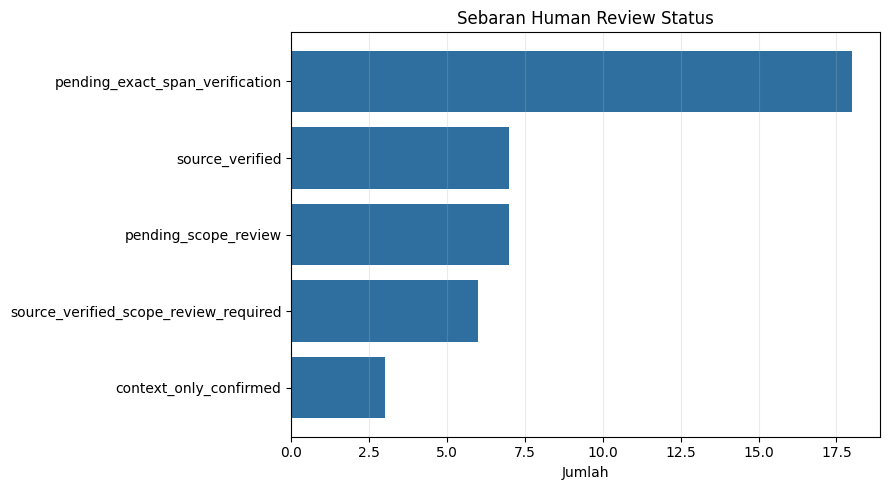

In [82]:
plot_bar("analysis_eligibility", "Sebaran Analysis Eligibility")
plot_bar("evaluation_eligibility", "Sebaran Evaluation Eligibility")
plot_bar("label_status", "Sebaran Label Status")
plot_horizontal_bar("human_review_status", "Sebaran Human Review Status", top=10)

## 4. Sebaran Korpus dan Scope

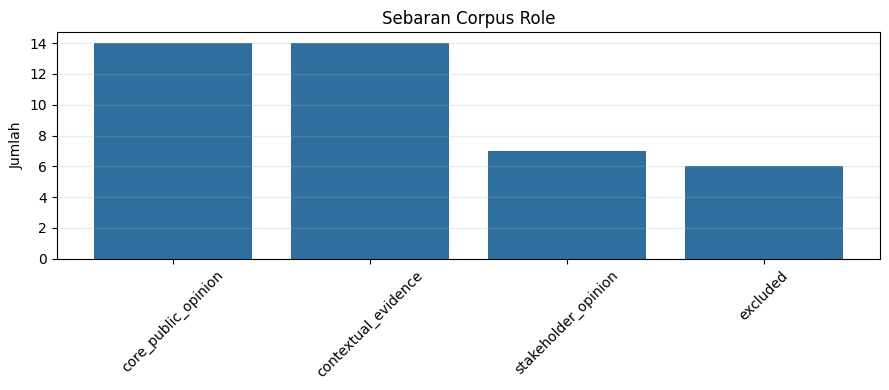

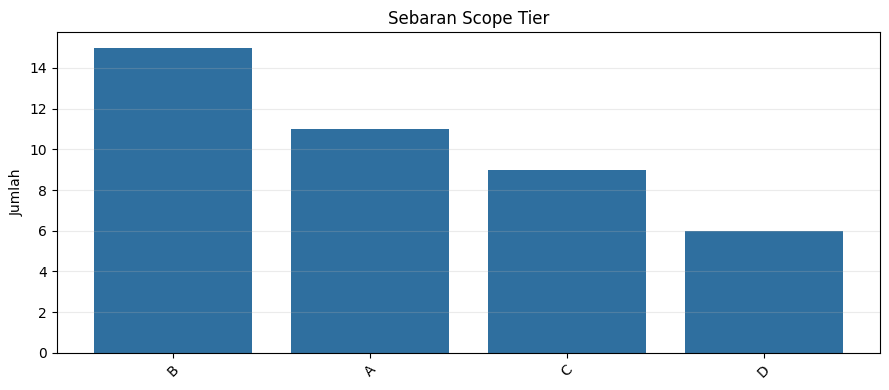

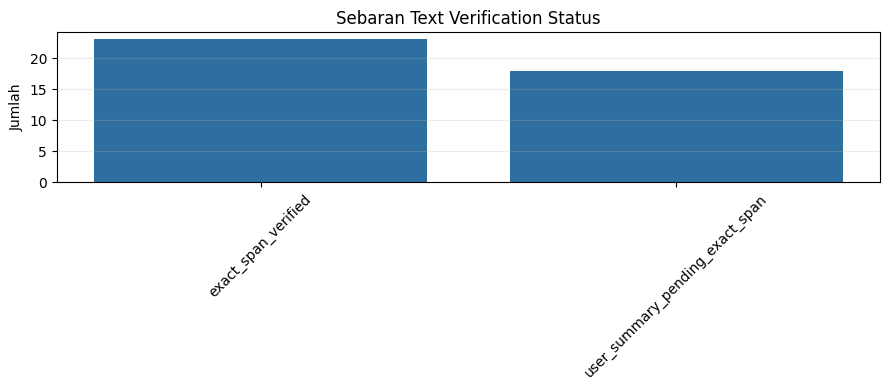

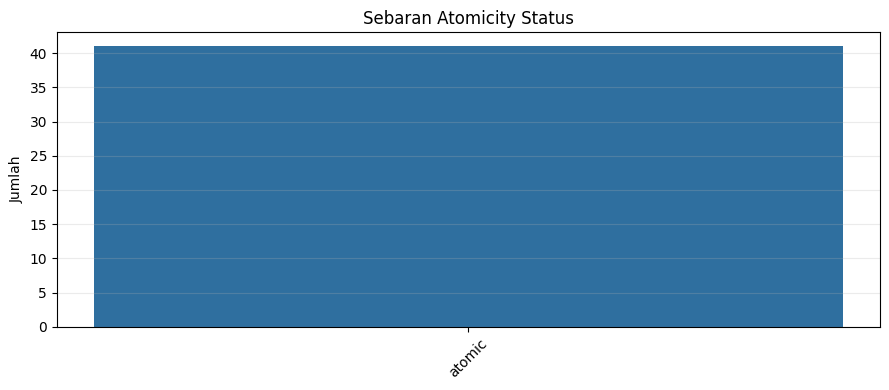

In [83]:
plot_bar("corpus_role", "Sebaran Corpus Role")
plot_bar("scope_tier", "Sebaran Scope Tier")
plot_bar("text_verification_status", "Sebaran Text Verification Status")
plot_bar("atomicity_status", "Sebaran Atomicity Status")

## 5. Sebaran Sumber dan Event

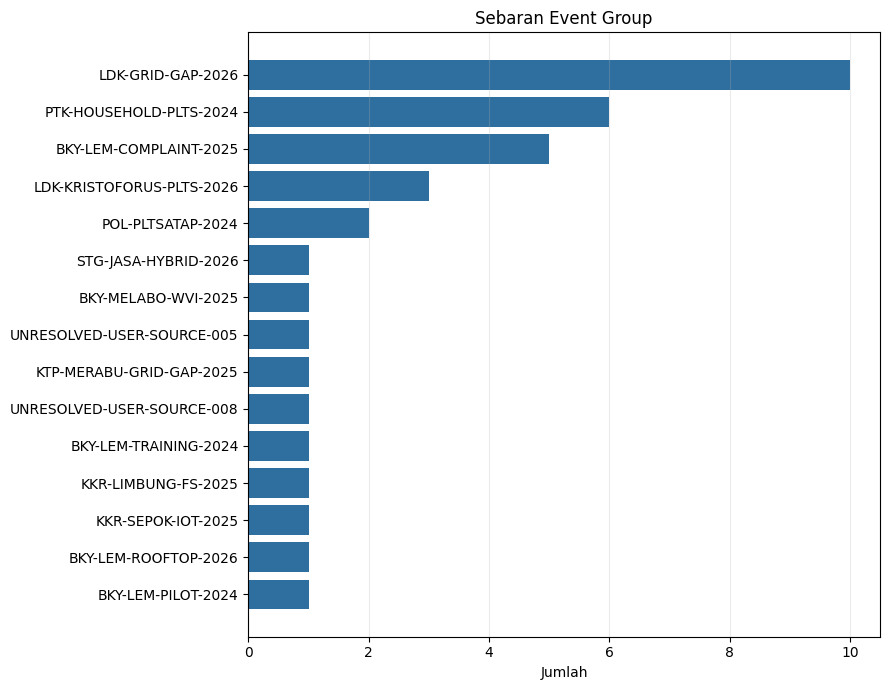

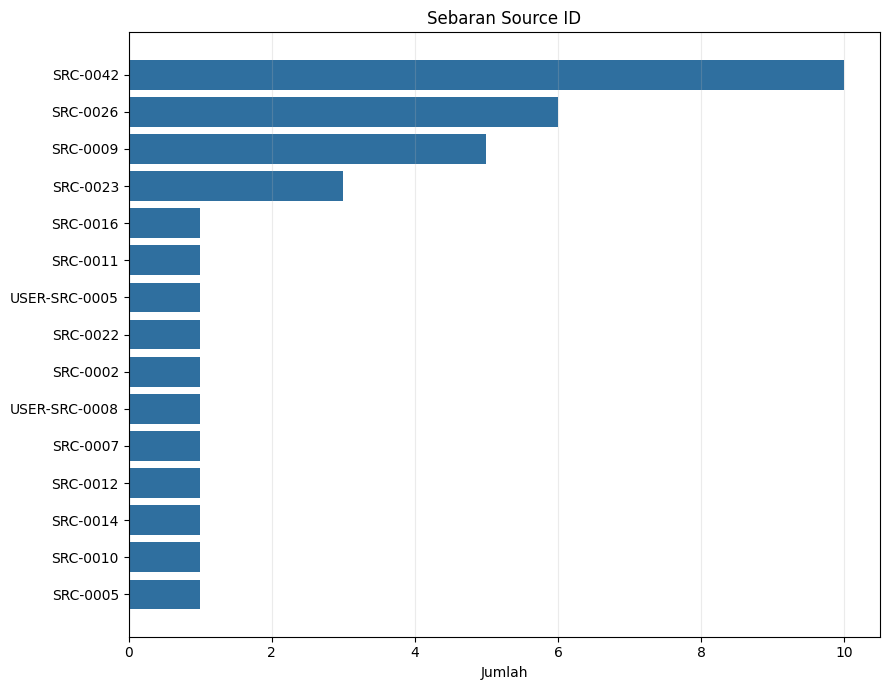

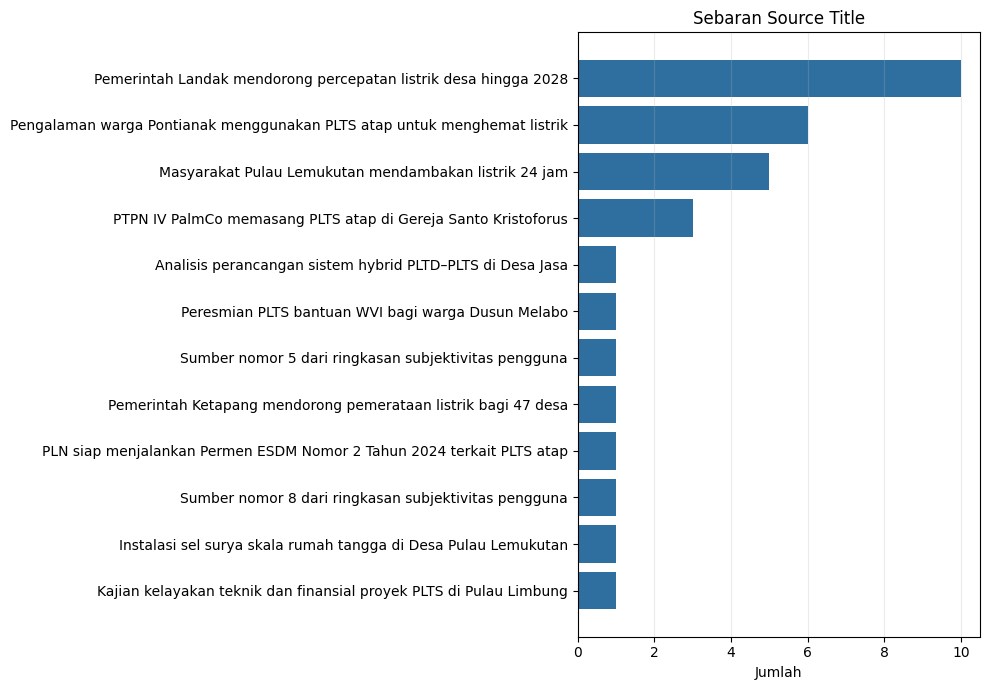

In [84]:
plot_horizontal_bar("event_group", "Sebaran Event Group", top=15, figsize=(9, 7))
plot_horizontal_bar("source_id", "Sebaran Source ID", top=15, figsize=(9, 7))
plot_horizontal_bar("source_title", "Sebaran Source Title", top=12, figsize=(10, 7))

## 6. Sebaran Pembicara dan Jenis Kutipan

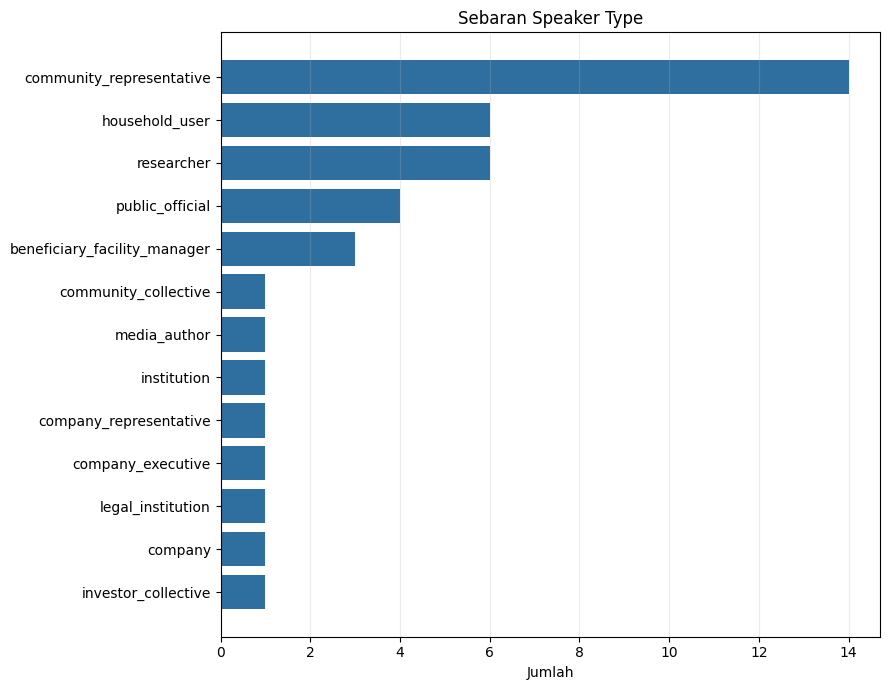

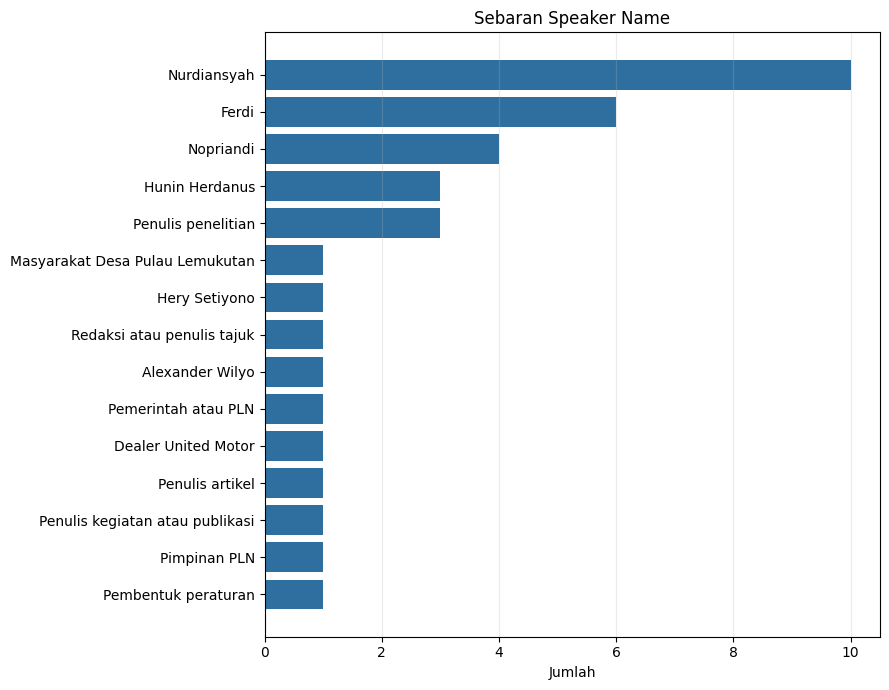

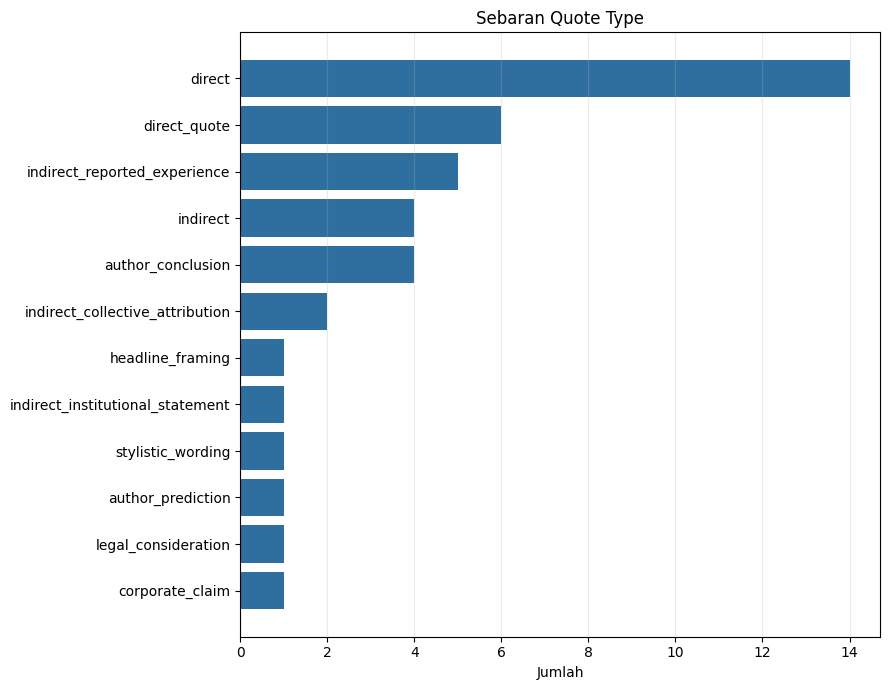

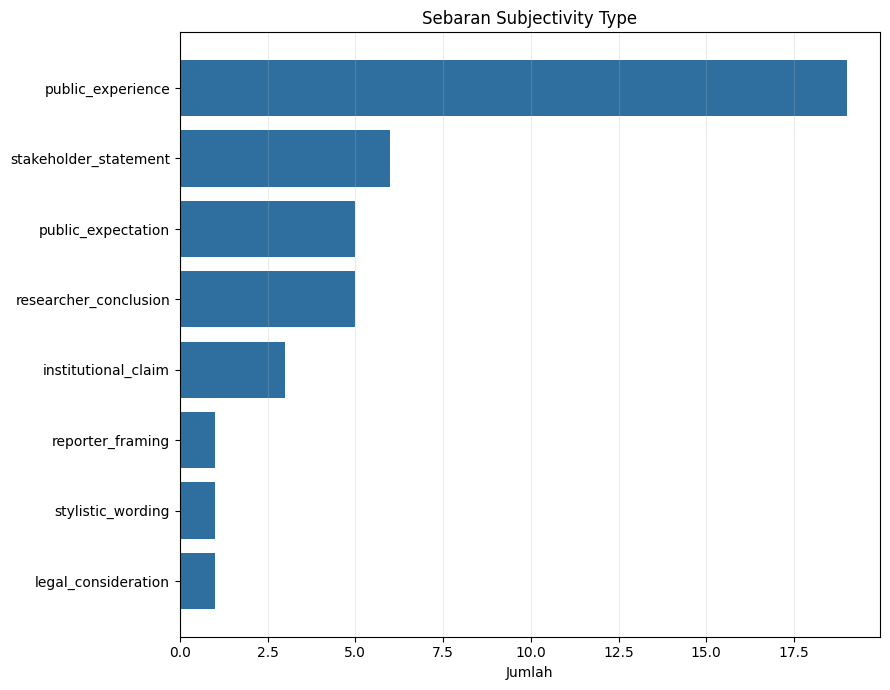

In [85]:
plot_horizontal_bar("speaker_type", "Sebaran Speaker Type", top=15, figsize=(9, 7))
plot_horizontal_bar("speaker_name", "Sebaran Speaker Name", top=15, figsize=(9, 7))
plot_horizontal_bar("quote_type", "Sebaran Quote Type", top=15, figsize=(9, 7))
plot_horizontal_bar("subjectivity_type", "Sebaran Subjectivity Type", top=15, figsize=(9, 7))

## 7. Sebaran Target dan Aspek

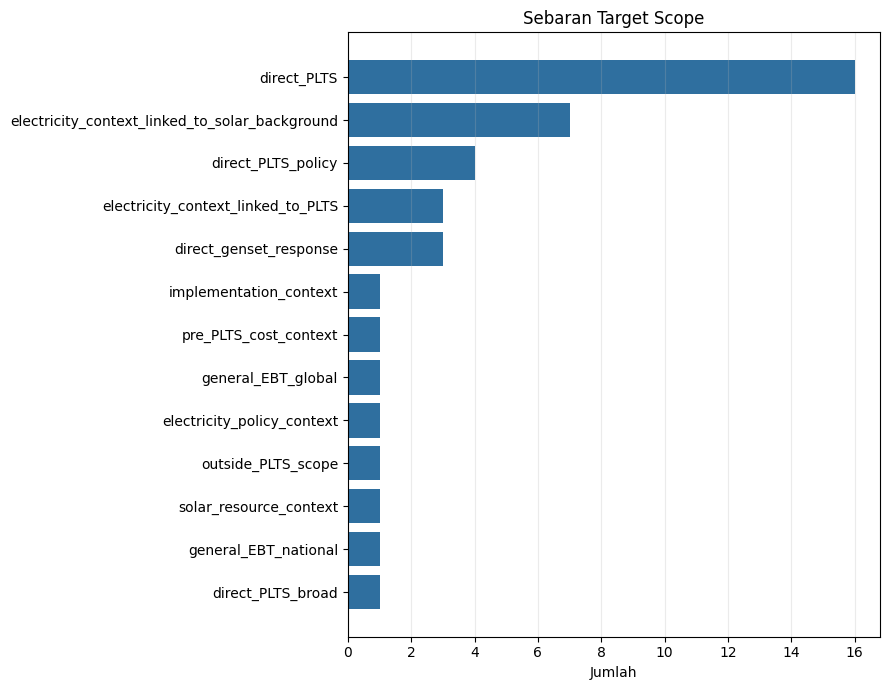

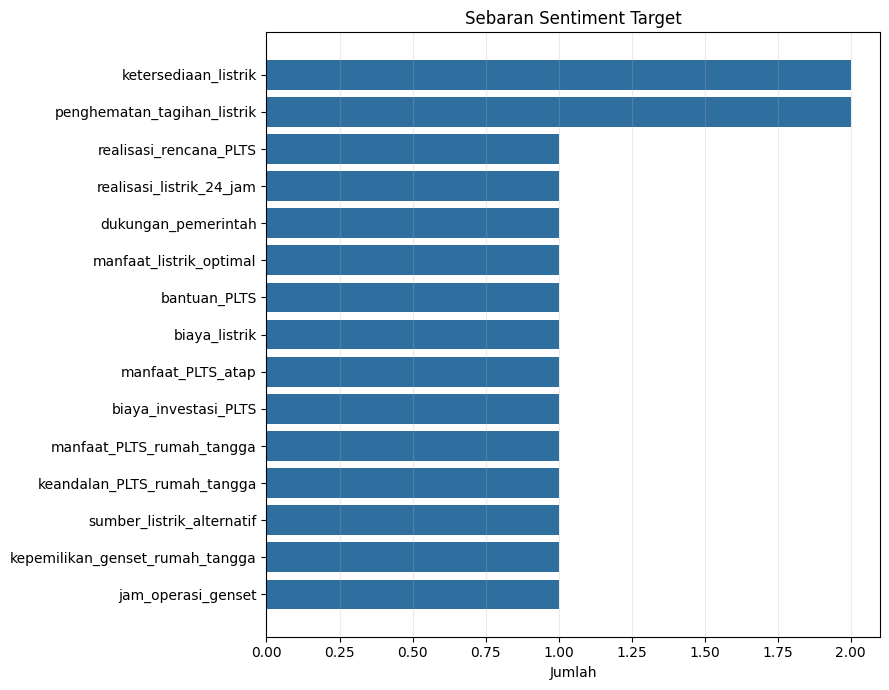

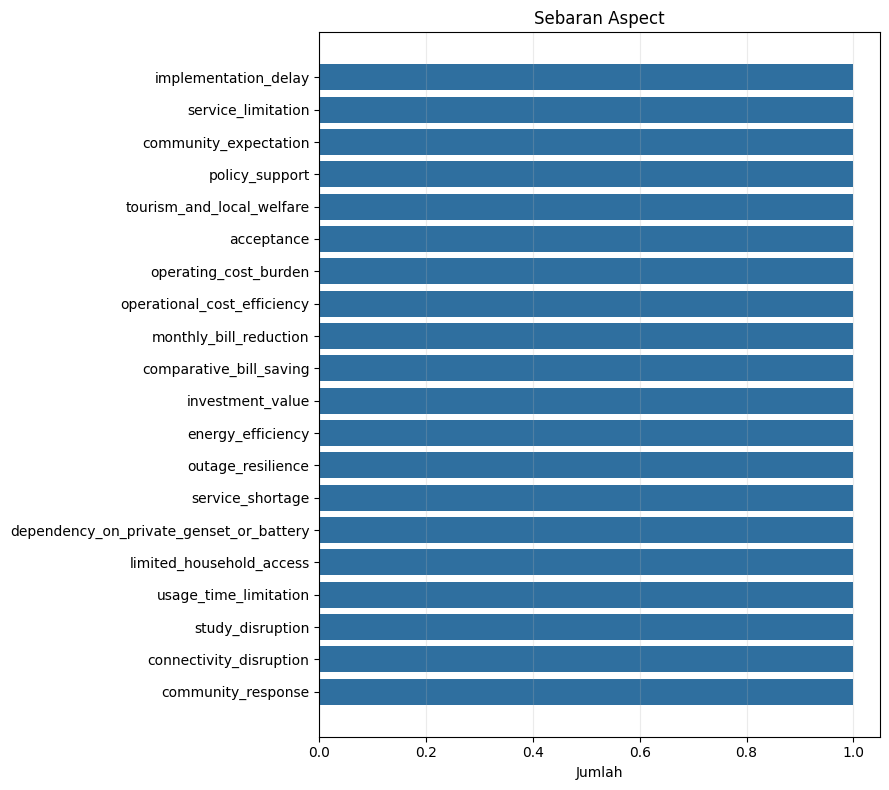

In [86]:
plot_horizontal_bar("target_scope", "Sebaran Target Scope", top=15, figsize=(9, 7))
plot_horizontal_bar("sentiment_target", "Sebaran Sentiment Target", top=15, figsize=(9, 7))
plot_horizontal_bar("aspect", "Sebaran Aspect", top=20, figsize=(9, 8))

## 8. Kelengkapan Kolom

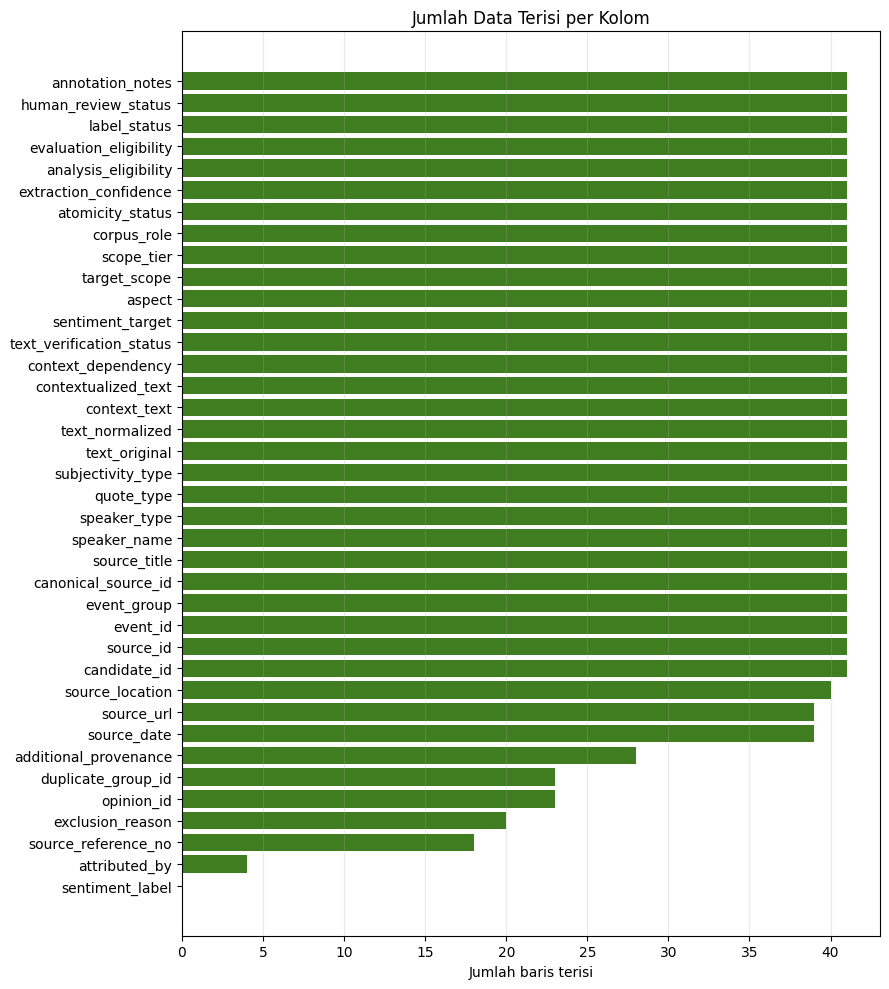

In [87]:
filled_counts = {}
for column in columns:
    filled_counts[column] = sum(1 for row in rows if row.get(column, ""))

items = sorted(filled_counts.items(), key=lambda item: item[1])
labels = [item[0] for item in items]
values = [item[1] for item in items]

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(labels, values, color="#3f7d20")
ax.set_title("Jumlah Data Terisi per Kolom")
ax.set_xlabel("Jumlah baris terisi")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "filled_columns.png", dpi=160)
plt.show()

## 9. Sebaran Tanggal Sumber

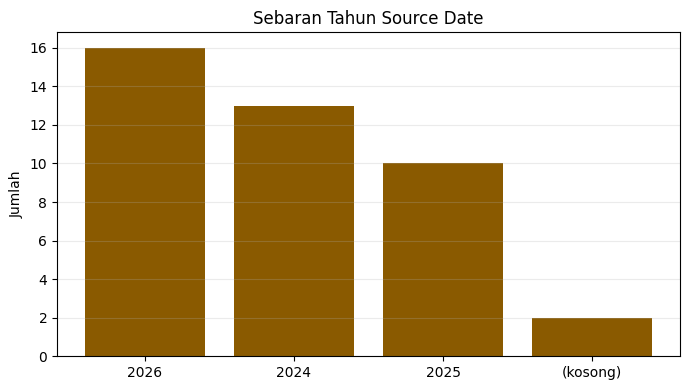

In [88]:
source_years = []
for row in rows:
    source_date = row.get("source_date", "")
    source_years.append(source_date[:4] if source_date else "(kosong)")

year_counts = dict(Counter(source_years).most_common())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(year_counts.keys(), year_counts.values(), color="#8a5a00")
ax.set_title("Sebaran Tahun Source Date")
ax.set_ylabel("Jumlah")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "source_year.png", dpi=160)
plt.show()